<a href="https://colab.research.google.com/github/Aleksandrovna15/Data-Science-Capstone-Project/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis
### Alisa Fedorova and Jenna Chiaramonte

## Data Loading and Preprocessing

A small pilot dataset is created by utiling .xml files from Perseus and TOROT treebanks for *The Orations of Marcus Tullius: In Catilina* and *The Primary Russian Chronicle*, hosted on Github (insert links here). The form of the data goes as follows:

**Tokens DataFrame**




*   `sentence_id`: sentence number
*   `form`: inflected version of word used in the text
*   `lemma`: base form of word
*   `tag`: codes positionally for morphology
    * Perseus `postag` field encodes positional morphology. This will be extracted using a small parser function. For example: `v2sfid---` encodes that the token is a verb, in 2nd person, singular, future, indicative and deponent.
    * Part of speech, person, number, tense, mood, voice, gender, case, degree (in this order)

**Sentences DataFrame**


*   `sentence_id`: sentence number
*   `text`: source text
*   `MT`: machine translation
*   `ref`: reference human translation
*   `score`: evaluation score (BLEURT/COMET)

*   `case density`: tokens marked for case out of total tokens
*   `length`: number of tokens in sentence

In [ ]:
# import libraries and dependencies
import xml.etree.ElementTree as et
import pandas as pd

In [ ]:
with open("in_catilinia.txt") as f:
  contents = f.read()
  catilina = contents.split("\n")
  catilina.insert(0, "")
  print(catilina)

['', 'When, O Catiline, do you mean to cease abusing our patience?', 'How long is that madness of yours still to mock us?', 'When is there to be an end of that unbridled audacity of yours, swaggering about as it does now?', 'Do not the nightly guards placed on the Palatine Hill—do not the watches posted throughout the city—does not the alarm of the people, and the union of all good men—does not the precaution taken of assembling the senate in this most defensible place—do not the looks and countenances of this venerable body here present, have any effect upon you?', 'Do you not feel that your plans are detected? Do you not see that your conspiracy is already arrested and rendered powerless by the knowledge which every one here possesses of it?', 'What is there that you did last night, what the night before—where were you—who was there that you summoned to meet you—what design was there which was adopted by you, with which you think that any one of us is unacquainted?', 'Shame on the ag

In [ ]:
with open("chronicle2.txt") as f:
  contents = f.read()
  chronicle = contents.split("\n")
  chronicle.insert(0, "")
  print(chronicle)

['', '6453', "In this year, Igor's retinue said to him,", '"The servants of Sveinald are adorned with weapons and fine raiment,', 'but we are naked', 'Go forth with us, oh Prince, after tribute, that both you and we may profit thereby."', "Igor' heeded their words,", 'and he attacked Dereva in search of tribute.', 'He sought to increase the previous tribute ', 'and collected it by violence from the people with the assistance of his followers.', 'After thus gathering the tribute, he returned to his city.', 'On his homeward way, he said to his followers, after some reflection,', '"Go forward with the tribute.', 'I shall turn back,', 'and rejoin you later."', 'He dismissed his retainers on their journey homeward', 'but being desirous of still greater booty he returned on his tracks with a few of his followers.', 'The Derevlians heard that he was again approaching, and consulted with Mal, their prince, saying,', '"If a wolf come among the sheep, he will take away the whole flock one by one

In [ ]:
# read in xml using etree
tree = et.parse("rus.lav.xml")
root = tree.getroot()

In [ ]:
def torot_morphology(morph):

  features = {
      "person": None,
      "number": None,
      "tense": None,
      "mood": None,
      "voice": None,
      "gender": None,
      "case": None,
      "degree": None
  }

  if not morph:
    return features

  morph = morph.ljust(10, "-") # pad if needed
  # mapping positional codings to features
  number_map = {"s": "singular", "p": "plural", "d": "dual"}
  gender_map = {"m": "masculine", "f": "feminine", "n": "neuter"}
  case_map = {
      "n": "nominative",
      "g": "genitive",
      "d": "dative",
      "a": "accusative",
      "i": "instrumental",
      "l": "locative",
      "v": "vocative"
  }

  tense_map = {
      "p": "present",
      "a": "aorist",
      "i": "imperfect",
      "f": "future",
      "r": "perfect"
  }

  mood_map = {
      "i": "indicative",
      "m": "imperative",
      "s": "subjunctive",
      "n": "infinitive"
  }

  voice_map = {
      "a": "active",
      "p": "passive",
      "m": "middle"
  }

  features["person"] = morph[0] if morph[0] in "123" else None
  features["number"] = number_map.get(morph[1])
  features["tense"] = tense_map.get(morph[2])
  features["mood"] = mood_map.get(morph[3])
  features["voice"] = voice_map.get(morph[4])
  features["gender"] = gender_map.get(morph[5])
  features["case"] = case_map.get(morph[6])
  features["degree"] = morph[7] if morph[7] != "-" else None

  return features

In [ ]:
def perseus_morphology(tag):

    features = {
        "pos": None,
        "person": None,
        "number": None,
        "tense": None,
        "mood": None,
        "voice": None,
        "gender": None,
        "case": None,
        "degree": None
    }

    if not tag:
        return features

    tag = tag.ljust(9, "-")

    pos_map = {
        "n": "noun",
        "v": "verb",
        "a": "adjective",
        "p": "pronoun",
        "r": "preposition",
        "d": "adverb",
        "c": "conjunction",
        "u": "punctuation",
        "m": "numeral",
        "i": "interjection"
    }

    number_map = {"s": "singular", "p": "plural", "d": "dual"}
    gender_map = {"m": "masculine", "f": "feminine", "n": "neuter"}
    case_map = {
        "n": "nominative",
        "g": "genitive",
        "d": "dative",
        "a": "accusative",
        "b": "ablative",
        "l": "locative",
        "v": "vocative"
    }

    tense_map = {
        "p": "present",
        "i": "imperfect",
        "f": "future",
        "r": "perfect",
        "l": "pluperfect",
        "t": "future perfect"
    }

    mood_map = {
        "i": "indicative",
        "s": "subjunctive",
        "m": "imperative",
        "n": "infinitive",
        "p": "participle",
        "u": "supine"
    }

    voice_map = {
        "a": "active",
        "p": "passive",
        "m": "middle"
    }

    pos = pos_map.get(tag[0])
    features["pos"] = pos

    if pos == "verb":
        features["person"] = tag[1] if tag[1] in "123" else None
        features["number"] = number_map.get(tag[2])
        features["tense"] = tense_map.get(tag[3])
        features["mood"] = mood_map.get(tag[4])
        features["voice"] = voice_map.get(tag[5])

    elif pos in ["noun", "adjective", "pronoun"]:
        features["number"] = number_map.get(tag[2])
        features["gender"] = gender_map.get(tag[3])
        features["case"] = case_map.get(tag[5])

    return features

In [ ]:
# need to dfs one at token-level and one at sentence-level
tokens = []
sentences = []

In [ ]:
TOROT_POS_MAP = {
    "Nb": "noun",
    "Ne": "proper_noun",
    "V-": "verb",
    "A-": "adjective",
    "Pk": "pronoun",
    "Pd": "demonstrative_pronoun",
    "Pp": "personal_pronoun",
    "R-": "preposition",
    "C-": "conjunction",
    "Df": "particle",
    "Dq": "adverb",
    "Ma": "numeral"
}

In [ ]:
def map_torot_pos(tag):
    if tag is None:
        return None
    return TOROT_POS_MAP.get(tag, "other")

In [ ]:
i = 1
for sentence in root.iter("sentence"):

  sent_id = sentence.attrib["id"]
  ref = chronicle[i] if i < len(chronicle) else None
  i += 1
  complete_sentence = ""
  for token in sentence.iter("token"):
    form = token.attrib.get("form")
    lemma = token.attrib.get("lemma")
    pos = token.attrib.get("part-of-speech")
    pos = map_torot_pos(pos)

    morph_tag = token.attrib.get("morphology")
    features = torot_morphology(morph_tag)

    if form == None:
      continue
    complete_sentence += form + " "
    tokens.append({
        "sentence_id": "Primary_Chronicle_" + sent_id,
        "form": form,
        "lemma": lemma,
        "tag": morph_tag,
        "pos": pos,
        **features
    })
  sentences.append({"sentence_id": "Primary_Chronicle_" + sent_id, "text": complete_sentence, "human_ref": ref, "length": len(complete_sentence)})

In [ ]:
tree = et.parse("lat.phi0474.phi013.xml")
root = tree.getroot()

In [ ]:
# need to dfs one at token-level and one at sentence-level

for sentence in root.iter("sentence"):

  sent_id = sentence.attrib["id"]
  complete_sentence = ""
  ref = catilina[int(sent_id)]

  for token in sentence.iter("word"):
    form = token.attrib.get("form")
    lemma = token.attrib.get("lemma")
    postag = token.attrib.get("postag")
    features = perseus_morphology(postag)

    complete_sentence += form + " "
    tokens.append({
        "sentence_id": "Tullius_Catilina_" + sent_id,
        "form": form,
        "lemma": lemma,
        "tag": postag,
        **features
    })
  sentences.append({"sentence_id": "Tullius_Catilina_" + sent_id, "text": complete_sentence, "human_ref": ref, "length": len(complete_sentence)})

In [ ]:
df_tokens = pd.DataFrame(tokens)

In [ ]:
df_tokens.head(10)

,sentence_id,form,lemma,tag,pos,person,number,tense,mood,voice,gender,case,degree
0,Primary_Chronicle_125275,В,въ,---------n,preposition,None,None,None,None,None,None,None,None
1,Primary_Chronicle_125275,лѣт,лѣто,-s---na--i,noun,None,singular,None,None,None,neuter,accusative,None
2,Primary_Chronicle_125275,҂ѕ҃,шесть тысячь,---------n,numeral,None,None,None,None,None,None,None,None
3,Primary_Chronicle_125275,у҃,четырисъта,---------n,numeral,None,None,None,None,None,None,None,None
4,Primary_Chronicle_125275,н҃,пятьдесятъ,---------n,numeral,None,None,None,None,None,None,None,None
5,Primary_Chronicle_125275,г,трие,---------n,numeral,None,None,None,None,None,None,None,None
6,Primary_Chronicle_156453,В,въ,---------n,preposition,None,None,None,None,None,None,None,None
7,Primary_Chronicle_156453,се,сии,-s---na--i,demonstrative_pronoun,None,singular,None,None,None,neuter,accusative,None
8,Primary_Chronicle_156453,же,же,---------n,particle,None,None,None,None,None,None,None,None
9,Primary_Chronicle_156453,лѣто,лѣто,-s---na--i,noun,None,singular,None,None,None,neuter,accusative,None


In [ ]:
df_sentences = pd.DataFrame(sentences)

In [ ]:
df_sentences.head(10)

,sentence_id,text,human_ref,length
0,Primary_Chronicle_125275,В лѣт ҂ѕ҃ у҃ н҃ г,6453,18
1,Primary_Chronicle_156453,В се же лѣто рекоша дружина игореви,"In this year, Igor's retinue said to him,",36
2,Primary_Chronicle_140937,ѡтроци свѣньлъжи изодѣли сѧ суть ѡружьемъ и по...,"""The servants of Sveinald are adorned with wea...",50
3,Primary_Chronicle_125278,а мы нази,but we are naked,10
4,Primary_Chronicle_125279,поиди кнѧже с нами в дань да и ты добудеши и мы,"Go forth with us, oh Prince, after tribute, th...",48
5,Primary_Chronicle_125281,послуша ихъ игорь,"Igor' heeded their words,",18
6,Primary_Chronicle_125282,иде в дерева в дань,and he attacked Dereva in search of tribute.,20
7,Primary_Chronicle_125283,и примышлѧше къ первои даи,He sought to increase the previous tribute,27
8,Primary_Chronicle_140938,насилѧше имъ и мужи его,and collected it by violence from the people w...,24
9,Primary_Chronicle_125285,возьемавъ дань поиде въ градъ свои,"After thus gathering the tribute, he returned ...",35


## Descriptive Statistics and Preliminary Analyses

In [ ]:
df_tokens.describe()

,sentence_id,form,lemma,tag,pos,person,number,tense,mood,voice,gender,case,degree
count,950,950,950,950,920,157,566,181,178,176,109,113,9
unique,75,562,423,201,14,3,2,6,5,2,3,7,2
top,Tullius_Catilina_20,",",comma1,u--------,noun,3,singular,present,indicative,active,masculine,nominative,p
freq,39,73,67,125,203,100,424,100,105,140,76,39,8


In [ ]:
df_sentences.describe()

,length
count,75.000000
mean,72.813333
std,59.176487
min,8.000000
25%,22.000000
50%,54.000000
75%,111.500000
max,250.000000


In [ ]:
torot = df_tokens[df_tokens["sentence_id"].str.startswith("Primary")]
perseus = df_tokens[df_tokens["sentence_id"].str.startswith("Tullius")]

In [ ]:
print("Shape of df_tokens: ", df_tokens.shape)
print("Shape of df_sentences: ", df_sentences.shape)

Shape of df_tokens:  (950, 13)
Shape of df_sentences:  (75, 4)


In [ ]:
print("Number of unique tokens: ", df_tokens["form"].nunique())
print("Number of unique lemmas: ", df_tokens["lemma"].nunique())

Number of unique tokens:  562
Number of unique lemmas:  423


In [ ]:
print("Parts of speech for Old Russian: ", torot["pos"].unique())
print("Parts of speech for Latin: ", perseus["pos"].unique())

Parts of speech for Old Russian:  ['preposition' 'noun' 'numeral' 'demonstrative_pronoun' 'particle' 'verb'
 'proper_noun' 'adjective' 'pronoun' 'conjunction' 'personal_pronoun'
 'other']
Parts of speech for Latin:  ['adverb' 'verb' 'punctuation' 'noun' 'pronoun' 'conjunction'
 'preposition' None 'adjective' 'numeral']


In [ ]:
perseus['case'].unique()

array([None], dtype=object)

## Univariate Analysis

To perform any univariate (single variable) analysis, we need to separate different texts/corpora. We will copy those into new DataFrames so that the original data is untouched.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#split into two DataFrames without modifying df_tokens
torot = df_tokens[df_tokens["sentence_id"].str.startswith("Primary")]
perseus = df_tokens[df_tokens["sentence_id"].str.startswith("Tullius")]

corpora = {
    "Primary Chronicle (TOROT)": torot,
    "In Catilinam (Perseus)":    perseus
}

palette = {
    "Primary Chronicle (TOROT)": "#1f77b4",
    "In Catilinam (Perseus)":    "#d62728"
}

To make each a bar graph for any variable, we can create a function that can customize each request.

In [ ]:
def plot_feature(feature, title, xlabel, verbal_only=False):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    fig.suptitle(title, fontsize=14, fontweight="bold")

    for ax, (corpus_name, grp) in zip(axes, corpora.items()):
        src = grp.dropna(subset=["tense"]) if verbal_only else grp
        counts = src[feature].dropna().value_counts()
        sns.barplot(x=counts.index, y=counts.values, ax=ax, color=palette[corpus_name])
        ax.set_title(corpus_name, fontsize=12)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Token Count")
        ax.tick_params(axis="x", rotation=35)

        # annotate bars with counts
        for bar in ax.patches:
            ax.annotate(
                f"{int(bar.get_height())}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=9
            )

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_feature_proportion(feature, title):
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle(title)

    for ax, (name, grp) in zip(axes, corpora.items()):
        dist = grp[feature].value_counts(normalize=True)
        sns.barplot(x=dist.index, y=dist.values, ax=ax, color=palette[name])
        ax.set_ylabel("Proportion")
        ax.set_title(name)
        ax.tick_params(axis="x", rotation=35)

    plt.tight_layout()
    plt.show()

Text(0.5, 1.0, 'Distribution of Sentence Lengths')

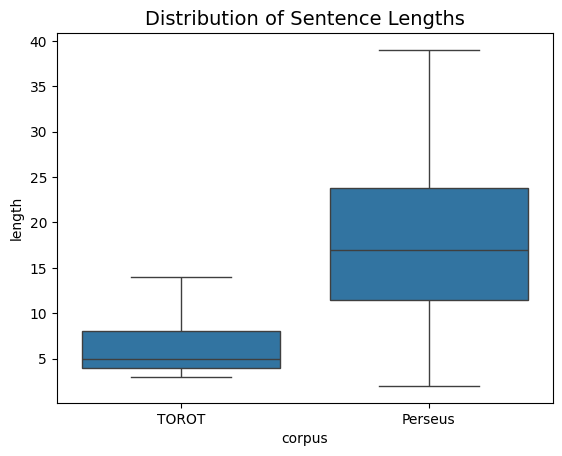

In [ ]:
torot_lengths = torot.groupby("sentence_id").size()
perseus_lengths = perseus.groupby("sentence_id").size()

lengths = pd.DataFrame({
    "length": pd.concat([torot_lengths, perseus_lengths]),
    "corpus": ["TOROT"]*len(torot_lengths) + ["Perseus"]*len(perseus_lengths)
})

sns.boxplot(data=lengths, x="corpus", y="length", showfliers=True)
plt.title("Distribution of Sentence Lengths", fontsize=14)

In [ ]:
import numpy as np

def plot_pos_signature():

    # POS frequencies
    torot_freq = torot["pos"].value_counts(normalize=True)
    perseus_freq = perseus["pos"].value_counts(normalize=True)

    # align indices
    pos = sorted(set(torot_freq.index) | set(perseus_freq.index))

    torot_freq = torot_freq.reindex(pos, fill_value=1e-6)
    perseus_freq = perseus_freq.reindex(pos, fill_value=1e-6)

    # log ratio
    signature = np.log(torot_freq / perseus_freq)

    sig_df = signature.sort_values()

    plt.figure(figsize=(10,6))
    colors = ["#d62728" if x < 0 else "#1f77b4" for x in sig_df.values]

    sns.barplot(x=sig_df.values, y=sig_df.index, palette=colors)

    plt.axvline(0, color="black", linestyle="--")

    plt.title("POS Signature Plot (Passages from The Primary Russian Chronicle vs In Catilinam)")
    plt.xlabel("Log Frequency Ratio")
    plt.ylabel("Part of Speech")

    plt.show()

/tmp/ipykernel_20071/1533100120.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sig_df.values, y=sig_df.index, palette=colors)


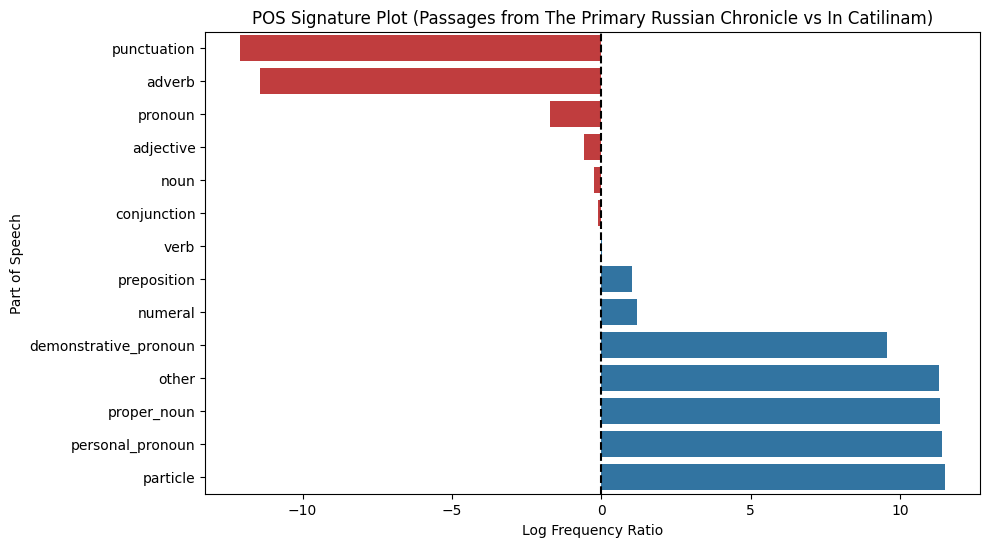

In [ ]:
plot_pos_signature()

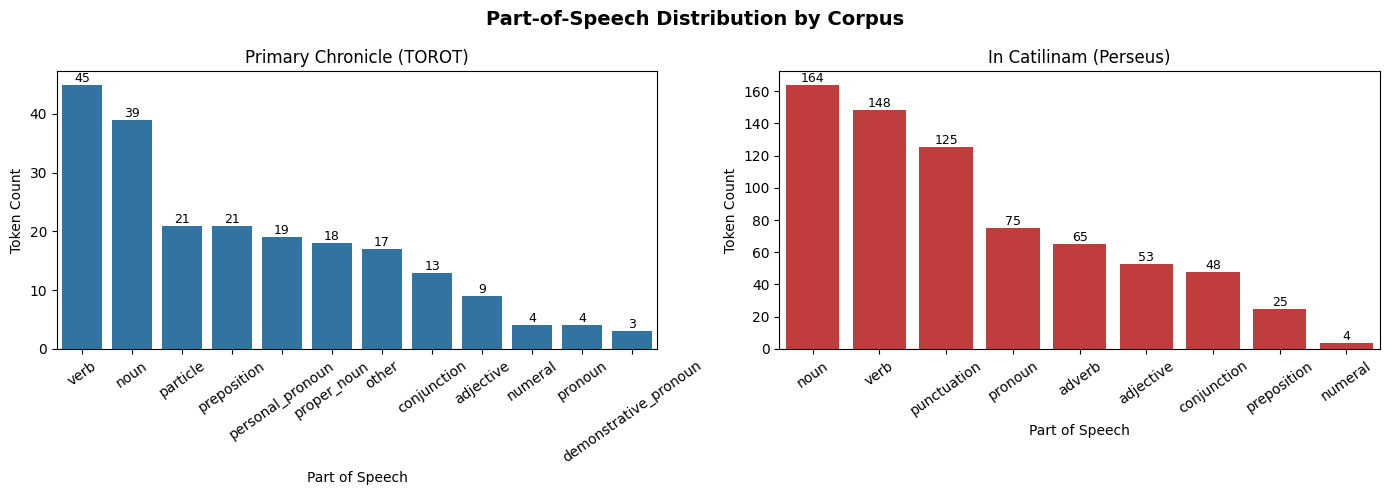

In [ ]:
plot_feature(
    feature="pos",
    title="Part-of-Speech Distribution by Corpus",
    xlabel="Part of Speech"
)

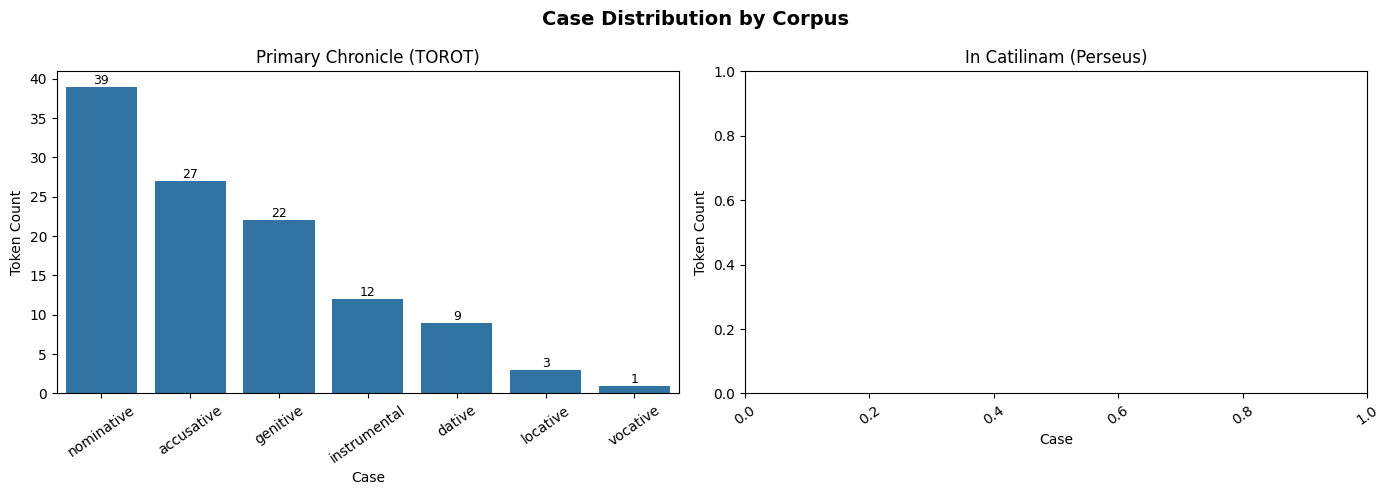

In [ ]:
plot_feature(
    feature="case",
    title="Case Distribution by Corpus",
    xlabel="Case"
)

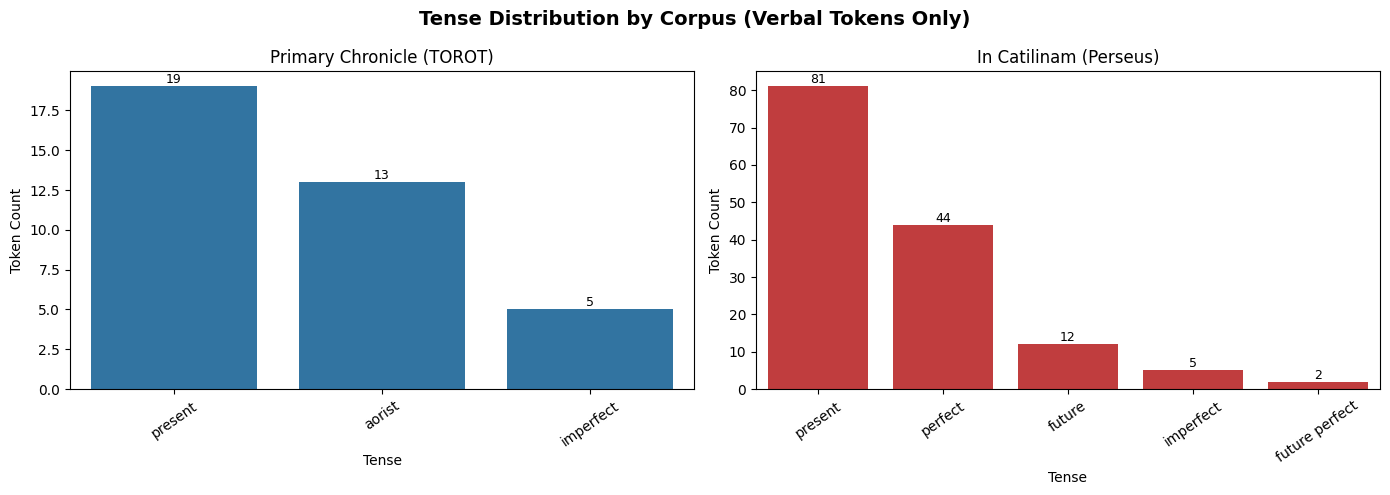

In [ ]:
plot_feature(
    feature="tense",
    title="Tense Distribution by Corpus (Verbal Tokens Only)",
    xlabel="Tense",
    verbal_only=True
)

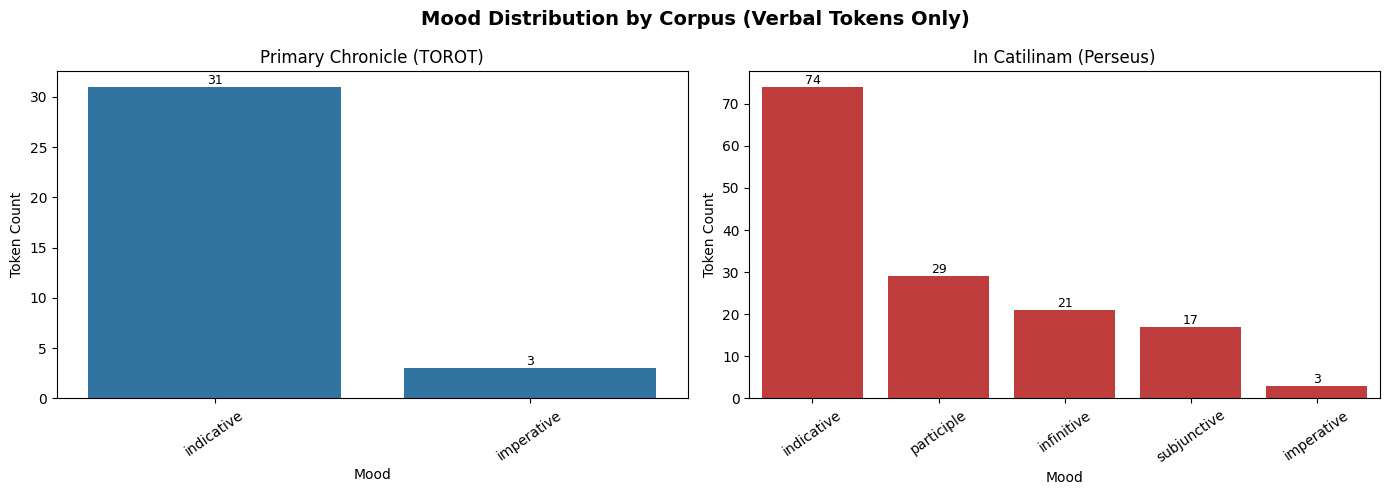

In [ ]:
plot_feature(
    feature="mood",
    title="Mood Distribution by Corpus (Verbal Tokens Only)",
    xlabel="Mood",
    verbal_only=True
)

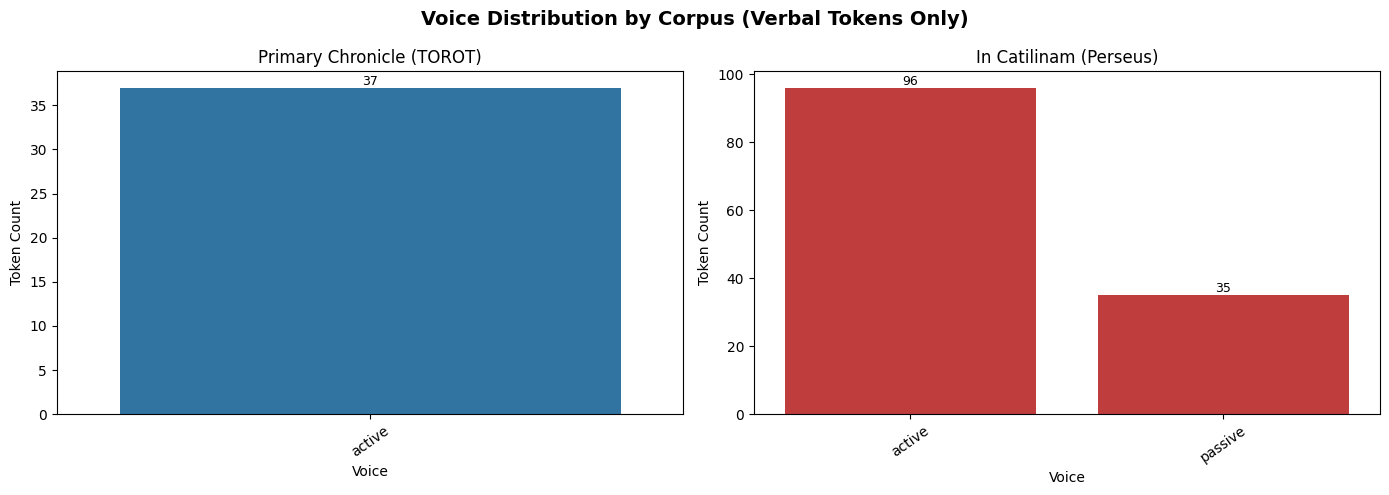

In [ ]:
plot_feature(
    feature="voice",
    title="Voice Distribution by Corpus (Verbal Tokens Only)",
    xlabel="Voice",
    verbal_only=True
)

## Multivariate Analysis

In [ ]:
# co-occurrence heatmap
def plot_heatmap(var1, var2, title, corpus_name, grp):
    cross = pd.crosstab(grp[var1].dropna(), grp[var2].dropna())
    if cross.empty:
        return
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(
        cross, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
        linecolor="white", ax=ax
    )
    ax.set_title(f"{title}\n{corpus_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel(var2.capitalize())
    ax.set_ylabel(var1.capitalize())
    plt.tight_layout()
    plt.show()

# grouped bar chart
def plot_grouped_bar(var1, var2, title, corpus_name, grp, color):
    cross = pd.crosstab(grp[var1].dropna(), grp[var2].dropna())
    if cross.empty:
        return
    ax = cross.plot(kind="bar", figsize=(12, 5), colormap="tab10", edgecolor="white")
    ax.set_title(f"{title}\n{corpus_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel(var1.capitalize())
    ax.set_ylabel("Token Count")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title=var2.capitalize(), bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# stacked bar chart
def plot_stacked_bar(var1, var2, title, corpus_name, grp):
    cross = pd.crosstab(grp[var1].dropna(), grp[var2].dropna(), normalize="index")
    if cross.empty:
        return
    ax = cross.plot(kind="bar", stacked=True, figsize=(12, 5),
                    colormap="tab10", edgecolor="white")
    ax.set_title(f"{title}\n{corpus_name}", fontsize=13, fontweight="bold")
    ax.set_xlabel(var1.capitalize())
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title=var2.capitalize(), bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

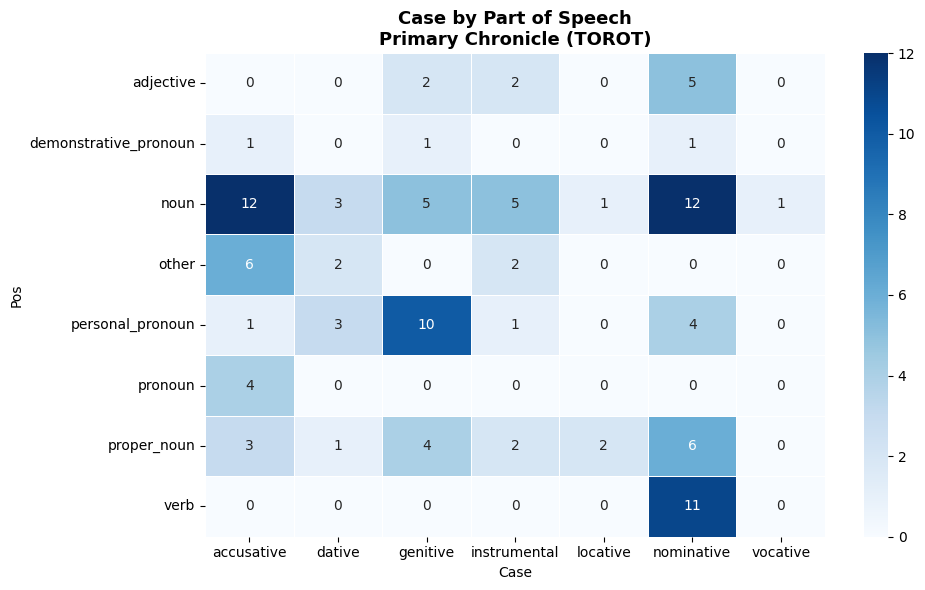

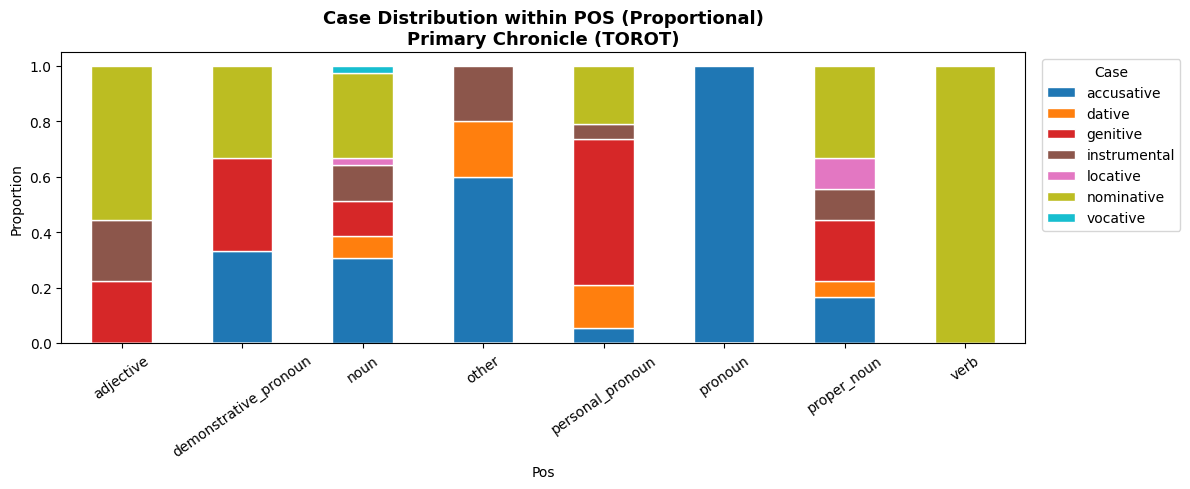

In [ ]:
# Case vs. POS — heatmap + stacked bar
# What parts of speech are carrying case in each corpus?
for corpus_name, grp in corpora.items():
    plot_heatmap("pos", "case", "Case by Part of Speech", corpus_name, grp)
    plot_stacked_bar("pos", "case", "Case Distribution within POS (Proportional)", corpus_name, grp)

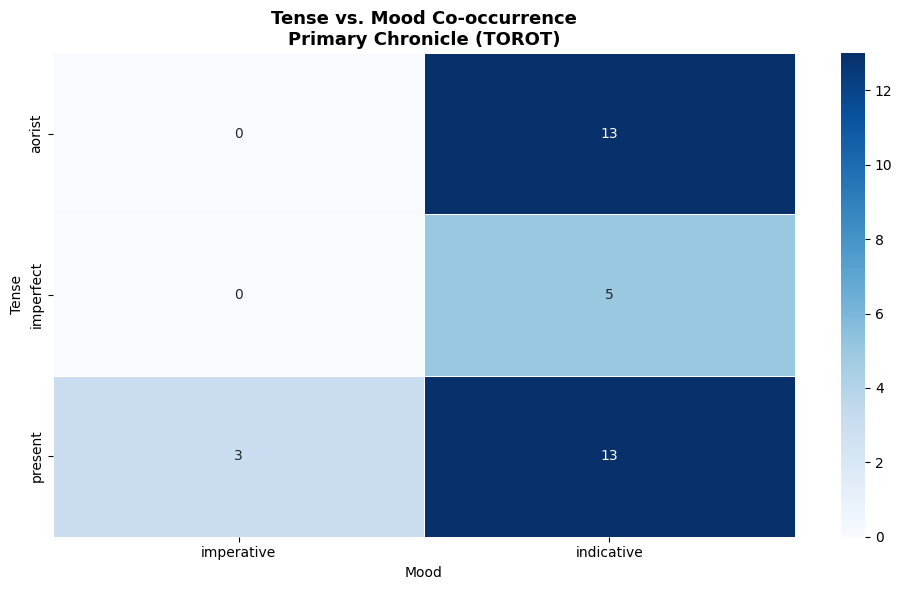

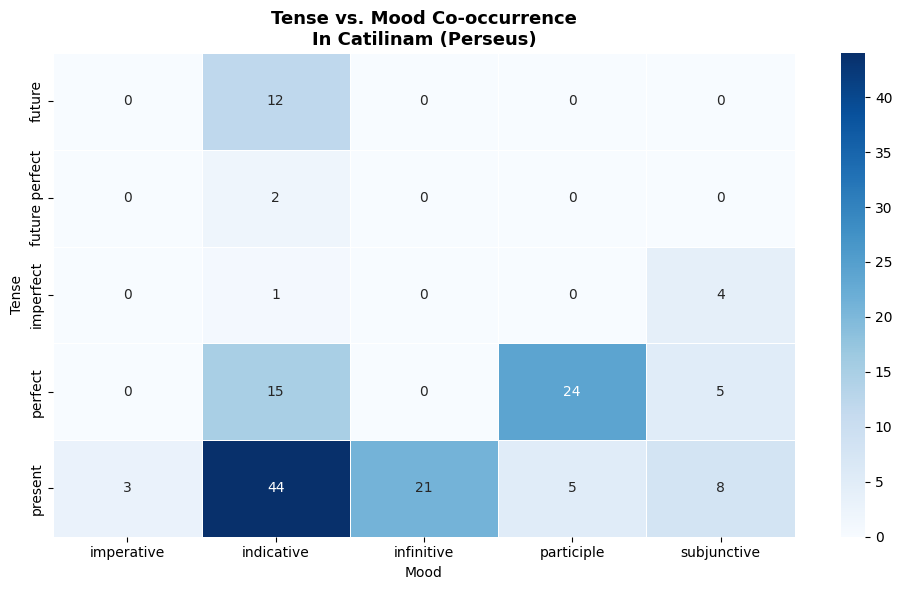

In [ ]:
# Tense vs. Mood — heatmap (verbal tokens only)
# Do certain tenses cluster with certain moods?
for corpus_name, grp in corpora.items():
    verbal = grp.dropna(subset=["tense", "mood"])
    plot_heatmap("tense", "mood", "Tense vs. Mood Co-occurrence", corpus_name, verbal)

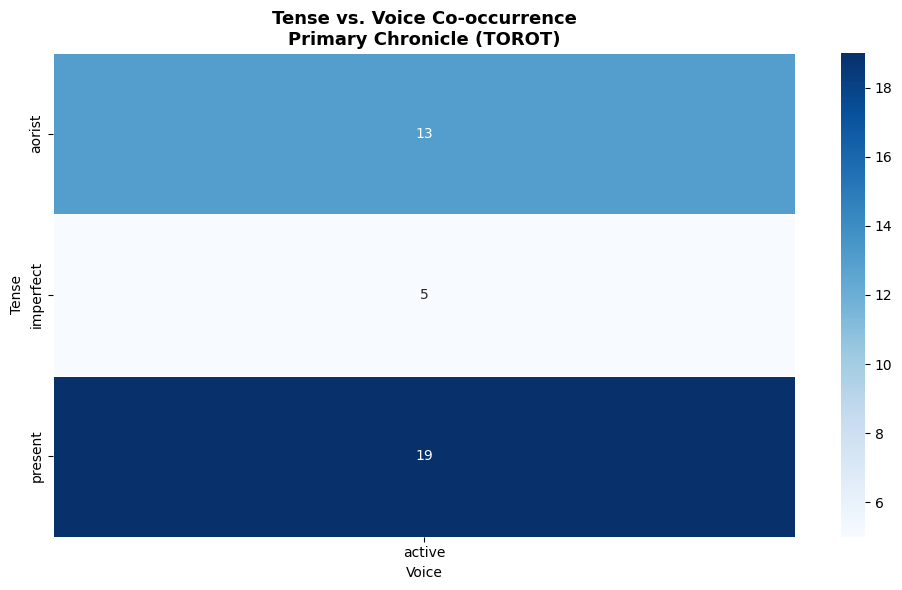

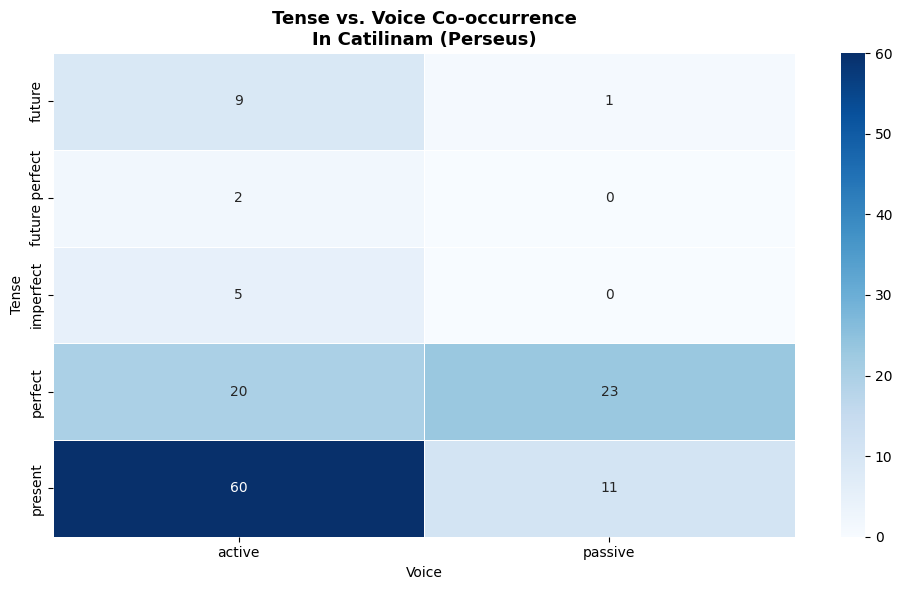

In [ ]:
# Tense vs. Voice — heatmap (verbal tokens only)
# Are certain voices more associated with particular tenses?
for corpus_name, grp in corpora.items():
    verbal = grp.dropna(subset=["tense", "voice"])
    plot_heatmap("tense", "voice", "Tense vs. Voice Co-occurrence", corpus_name, verbal)

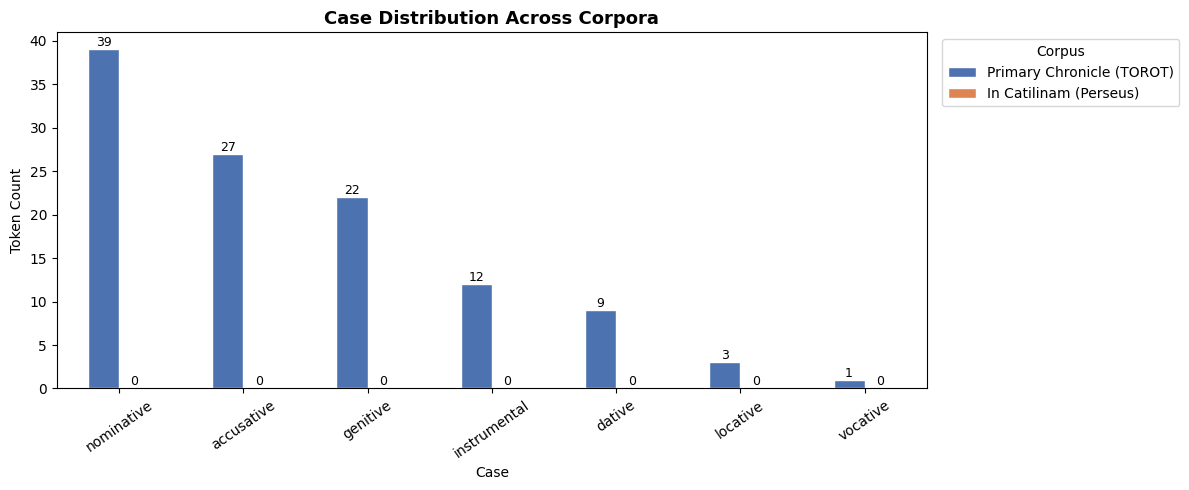

In [ ]:
# Case vs. Corpus — grouped bar comparing both corpora directly
# How do case profiles differ between Latin and Old East Slavic?
torot_case = torot["case"].dropna().value_counts().rename("Primary Chronicle (TOROT)")
perseus_case = perseus["case"].dropna().value_counts().rename("In Catilinam (Perseus)")
case_comparison = pd.concat([torot_case, perseus_case], axis=1).fillna(0)

ax = case_comparison.plot(
    kind="bar", figsize=(12, 5),
    color=["#4C72B0", "#DD8452"], edgecolor="white"
)
ax.set_title("Case Distribution Across Corpora", fontsize=13, fontweight="bold")
ax.set_xlabel("Case")
ax.set_ylabel("Token Count")
ax.tick_params(axis="x", rotation=35)
ax.legend(title="Corpus", bbox_to_anchor=(1.01, 1), loc="upper left")

for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_height())}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()